<a href="https://colab.research.google.com/github/Dawood-Ali123/Pytorch_learning/blob/main/ANNoptuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("preronakar/fminst")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fminst' dataset.
Path to dataset files: /kaggle/input/fminst


In [57]:
import os
filename=os.listdir(path)[0]

In [58]:
torch.manual_seed(42)

In [59]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [60]:
import pandas as pd
df=pd.read_csv(path+"/"+filename)

In [61]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


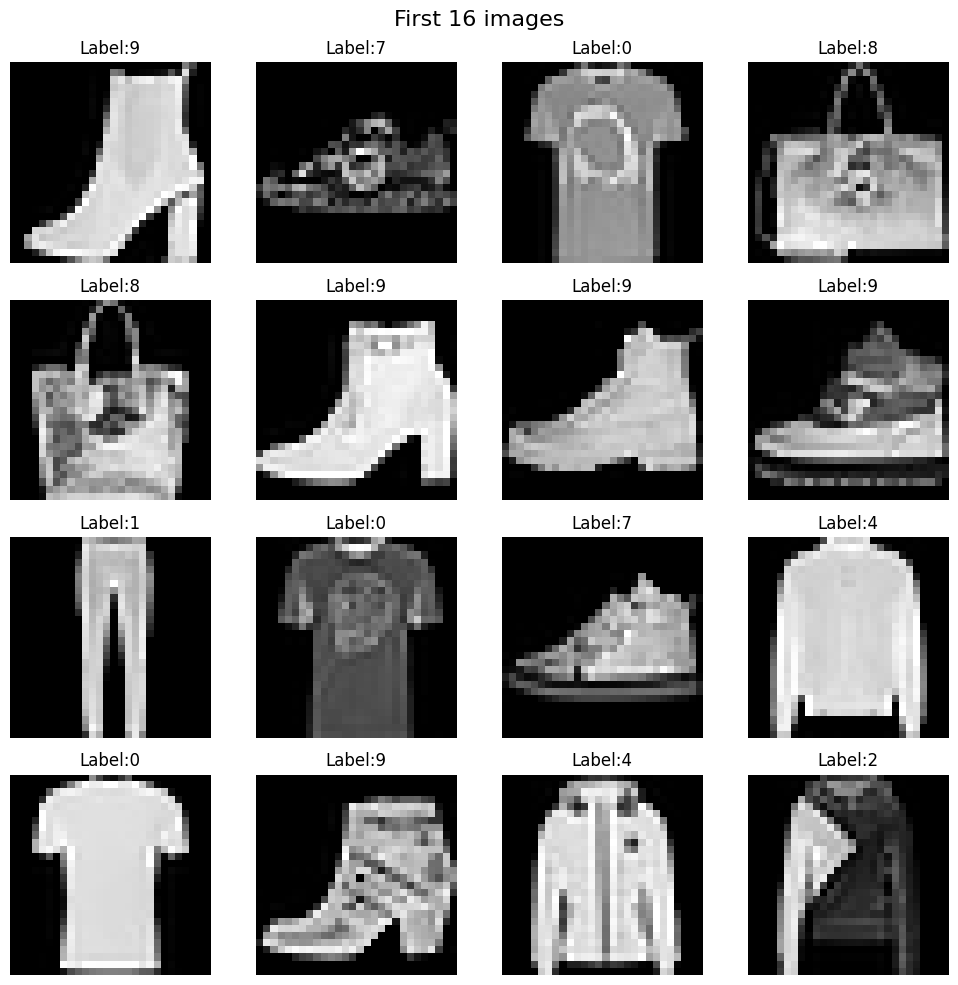

In [62]:
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 images",fontsize=16)
for i,ax in enumerate(axes.flat):
    ax.imshow(df.iloc[i,1:].values.reshape(28,28),cmap="gray")
    ax.axis("off")
    ax.set_title(f"Label:{df.iloc[i,0]}")
plt.tight_layout()
plt.show()

In [63]:
X=df.iloc[:,1:].values
Y=df.iloc[:,0]

In [64]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
X_train=X_train/255.0
Y_train=Y_train/255.0
X_test=X_test/255.0
Y_test=Y_test/255.0

In [65]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [66]:

Y_test=Y_test.to_numpy()

In [67]:
print(type(X_test))
print(type(Y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


Now we are going to create a custom data set class which inherit the properties from the data set class

In [68]:
class CustomDataset(Dataset):
  def __init__(self,features,lables):
    self.features=torch.tensor(features,dtype=torch.float32)
    self.lables=torch.tensor(lables,dtype=torch.long)
  def __len__(self):
    return len(self.features)
  def __getitem__(self,idx):
    return self.features[idx],self.lables[idx]

In [69]:
train_dataset=CustomDataset(X_train,Y_train)
print(len(train_dataset))
train_dataset[0]


4800


(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [70]:
test_dataset=CustomDataset(X_test,Y_test)
print(len(test_dataset))
test_dataset[0]

1200


(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [71]:
class MyNN(nn.Module):
  def __init__(self,input_dim,output_dim,num_hidden_layers,neurons_per_layer,dropout_rate):
    super().__init__()
    layers=[]
    for i in range(num_hidden_layers):
      layers.append(nn.Linear(input_dim,neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim=neurons_per_layer
    layers.append(nn.Linear(neurons_per_layer,output_dim))
    self.model=nn.Sequential(*layers)
  def forward(self,x):
    return self.model(x)


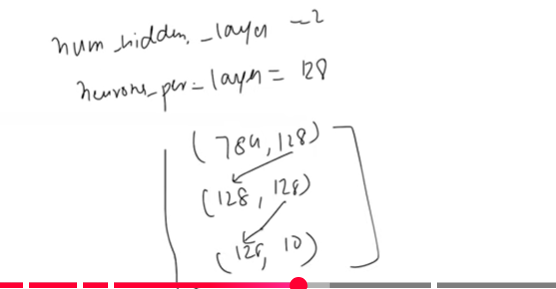

In [73]:
#objective function it is nothing but a python function
def objective(trial):
  #next hyperparamter values from the search space
  num_hidden_layers=trial.suggest_int("num_hidden_layers",1,5)
  num_neurons_per_layer=trial.suggest_int("num_neurons_per_layer",8,128)
  epochs=trial.suggest_int("epochs",10,50,step=10)
  learning_rate=trial.suggest_float("learning_rate",1e-5,1e-1,log=True)
  dropout_rate=trial.suggest_float("dropout_rate",0.1,0.5,step=0.1)
  batch_size=trial.suggest_categorical("batch_size",[32,64,128])
  optimizer=trial.suggest_categorical("optimizer",['Adam','SGD','RMSprop'])
  weight_decay=trial.suggest_float("weight_decay",1e-5,1e-1,log=True)
  #model init
  train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True,pin_memory=True)
  test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False,pin_memory=True)
  input_dim=X_train.shape[1]
  output_dim=10
  model=MyNN(input_dim,output_dim,num_hidden_layers,num_neurons_per_layer,dropout_rate)
  model.to(device)


  criterion=nn.CrossEntropyLoss()
  if optimizer=="Adam":
    optimizer=optim.Adam(model.parameters(),lr=learning_rate)
  elif optimizer=="RMSprop":
    optimizer=optim.RMSprop(model.parameters(),lr=learning_rate)
  else :
    optimizer=optim.SGD(model.parameters(),lr=learning_rate)

  #training loss
  for epoch in range(epochs):
     for batch_features,batch_lables in train_loader:
        batch_features=batch_features.to(device)
        batch_lables=batch_lables.to(device)
        #forward pass
        outputs=model(batch_features)
        #calculate loss
        loss=criterion(outputs,batch_lables)
        optimizer.zero_grad()
        #Back propagation
        loss.backward()
        #upgarede grads
        optimizer.step()
 #Model evaluation
  model.eval()
  #evaluation cod
  total=0
  correct=0
  with torch.no_grad():
    for batch_features,batch_lables in test_loader:

      batch_features=batch_features.to(device)
      batch_lables=batch_lables.to(device)
      outputs=model(batch_features)
      _,predicted=torch.max(outputs,1)
      total=total+batch_lables.size(0)
      correct=correct+(predicted==batch_lables).sum().item()
      accuracy=100*correct/total
    return accuracy


In [ ]:
!pip install optuna

In [74]:
import optuna
study=optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=10)

[I 2026-06-19 06:47:49,600] A new study created in memory with name: no-name-f99d8061-067f-441b-86de-5cd86ed6a7da
[I 2026-06-19 06:48:07,671] Trial 0 finished with value: 100.0 and parameters: {'num_hidden_layers': 3, 'num_neurons_per_layer': 51, 'epochs': 40, 'learning_rate': 0.004785419821872538, 'dropout_rate': 0.5, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.008557684539145334}. Best is trial 0 with value: 100.0.
[I 2026-06-19 06:48:09,578] Trial 1 finished with value: 100.0 and parameters: {'num_hidden_layers': 2, 'num_neurons_per_layer': 50, 'epochs': 10, 'learning_rate': 0.00026849944632249356, 'dropout_rate': 0.1, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.002602086021366634}. Best is trial 0 with value: 100.0.
[I 2026-06-19 06:48:17,350] Trial 2 finished with value: 100.0 and parameters: {'num_hidden_layers': 4, 'num_neurons_per_layer': 14, 'epochs': 50, 'learning_rate': 0.0002311205598306295, 'dropout_rate': 0.5, 'batch_size': 128, 'optimizer': '

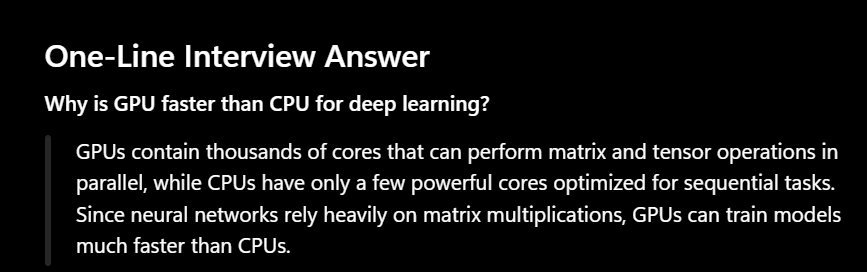

If the accuracy of the training data is greater then the test data then the model is overfitted but in our model every thing is ok but for example if our model is overfitted the we use these techniques 1:Adding more data 2:Reducing the complexity of the NN architecture
3:Droupouts
4:Data Agumentations
6:Batch Normalization
7:Early stoping

DropOut ya kuch Node ko pause kar deta ha training kay time pay jas sae network ki complexity kam ho jati ha magr ya testing kay time par wasa hi kam karta ha yahan par drop out kam nahi karty              
nn.Droupout(0.3)

Batch Normalization
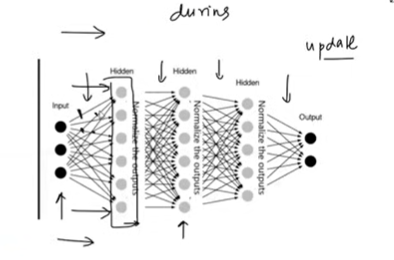 so jab input sae agly waly layer ko inupt jata ha tu us is data ka distribution kharab ho jata ha kun kay har output agly waly layer kay liya input ka kam karta ha to is ko hmien normaliza karna parta ha

Just like the droupout normalization also not work during the evaluation time


What is the Regulization technique is me ya hota ha kay hm apny loss fuction me ak panely add karty han jis sae high value attain nai ho pati